# Chapter 11: Classification


In this notebook, we explore classification models and logistic regression.

We will study:

- binary classification
- logistic regression
- probabilities and thresholds
- confusion matrices
- accuracy, precision, and recall
- changing classification thresholds


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)


## Binary Classification

In [3]:
# 0 = did not buy
# 1 = bought the product

purchase = [0, 0, 0, 1, 1, 1]

print(purchase)


[0, 0, 0, 1, 1, 1]



Many classification problems involve only two categories.

Examples:
- spam or not spam
- fraud or legitimate transaction
- customer churn or no churn


## The Logistic Curve

In [4]:
# Create values for the horizontal axis

x = np.linspace(-10, 10, 300)


In [5]:
# Logistic (sigmoid) function

y = 1 / (1 + np.exp(-x))


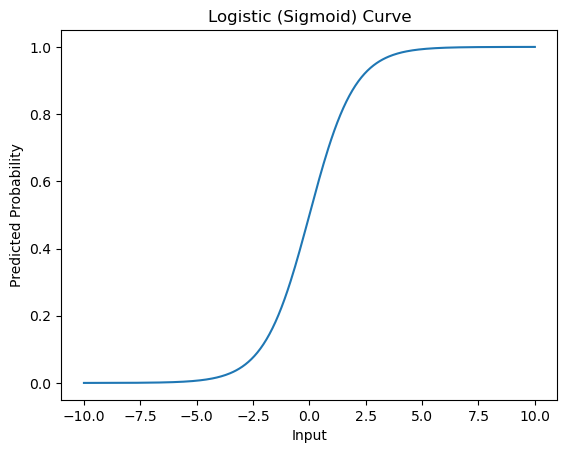

In [6]:
# Visualize the sigmoid curve

plt.plot(x, y)

plt.title("Logistic (Sigmoid) Curve")

plt.xlabel("Input")
plt.ylabel("Predicted Probability")

plt.show()



The logistic curve keeps probabilities between 0 and 1.


## From Probabilities to Class Predictions

In [7]:
# Predicted probabilities

probabilities = [0.12, 0.34, 0.52, 0.81, 0.93]

print(probabilities)


[0.12, 0.34, 0.52, 0.81, 0.93]


In [8]:
# Use a threshold of 0.5

predictions = []

for p in probabilities:

    if p > 0.5:
        predictions.append(1)

    else:
        predictions.append(0)

print(predictions)


[0, 0, 1, 1, 1]



Probabilities above 0.5 become class 1.

Probabilities below 0.5 become class 0.


## Logistic Regression Example

In [9]:
# Study hours and exam results

study_hours = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
])

# 0 = fail
# 1 = pass

exam_result = np.array([
    0, 0, 0, 0, 1,
    1, 1, 1, 1, 1
])


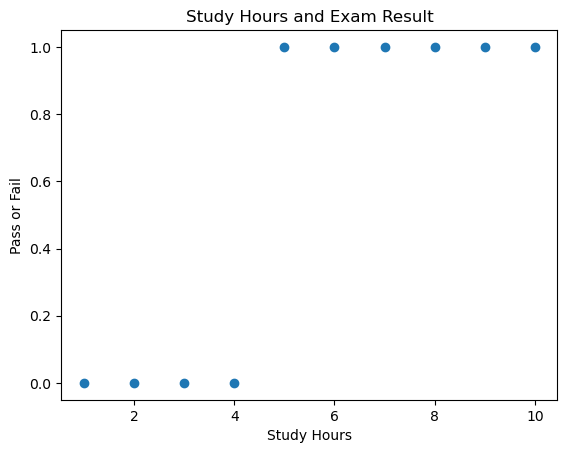

In [10]:
# Visualize the data

plt.scatter(study_hours, exam_result)

plt.title("Study Hours and Exam Result")

plt.xlabel("Study Hours")
plt.ylabel("Pass or Fail")

plt.show()


In [11]:
# Reshape the predictor variable

X = study_hours.reshape(-1, 1)

# Response variable

y = exam_result


In [12]:
# Create and train the logistic regression model

model = LogisticRegression()

model.fit(X, y)


LogisticRegression()

In [13]:
# Predicted probabilities

probabilities = model.predict_proba(X)

print(probabilities[:5])


[[0.98411136 0.01588864]
 [0.95002943 0.04997057]
 [0.85370783 0.14629217]
 [0.64173617 0.35826383]
 [0.35476293 0.64523707]]


In [14]:
# Probability of passing

pass_probability = probabilities[:, 1]

print(pass_probability)


[0.01588864 0.04997057 0.14629217 0.35826383 0.64523707 0.85560345
 0.95074895 0.98434822 0.99514302 0.99850412]


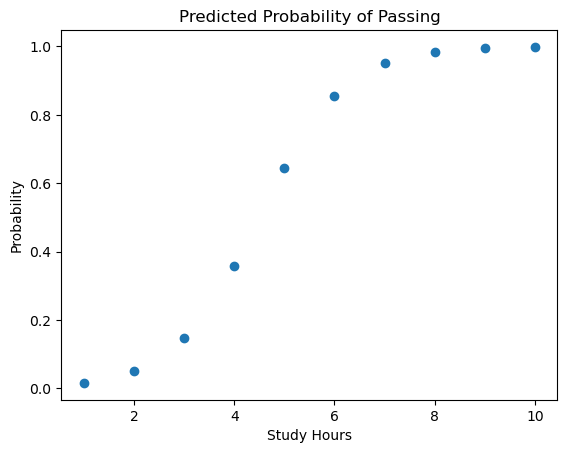

In [15]:
# Visualize predicted probabilities

plt.scatter(study_hours, pass_probability)

plt.title("Predicted Probability of Passing")

plt.xlabel("Study Hours")
plt.ylabel("Probability")

plt.show()


## Final Class Predictions

In [16]:
# Convert probabilities into class predictions

predictions = model.predict(X)

print(predictions)


[0 0 0 0 1 1 1 1 1 1]


## Confusion Matrix

In [17]:
# Compare actual values and predictions

matrix = confusion_matrix(y, predictions)

print(matrix)


[[4 0]
 [0 6]]



The confusion matrix contains:

- True Positives
- True Negatives
- False Positives
- False Negatives


## Accuracy

In [18]:
# Accuracy measures the fraction
# of correct predictions

accuracy = accuracy_score(y, predictions)

print("Accuracy:", round(accuracy, 2))


Accuracy: 1.0


## Precision

In [19]:
# Precision measures how trustworthy
# positive predictions are

precision = precision_score(y, predictions)

print("Precision:", round(precision, 2))


Precision: 1.0


## Recall

In [20]:
# Recall measures how well the model
# detects positive cases

recall = recall_score(y, predictions)

print("Recall:", round(recall, 2))


Recall: 1.0


## Changing the Threshold

In [21]:
# Use a larger threshold

threshold = 0.8

high_threshold_predictions = []


In [22]:
# Convert probabilities using the new threshold

for p in pass_probability:

    if p > threshold:
        high_threshold_predictions.append(1)

    else:
        high_threshold_predictions.append(0)

print(high_threshold_predictions)


[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]


In [23]:
# Compare predictions at threshold 0.8

matrix = confusion_matrix(y, high_threshold_predictions)

print(matrix)


[[4 0]
 [1 5]]



Larger thresholds make the model more cautious
before predicting the positive class.


# Appendix F: Additional Concepts in Classification

## Why Linear Regression Is Not Enough

In [24]:
# Linear regression can produce impossible probabilities

predictions = [-0.3, 0.4, 1.2]

print(predictions)


[-0.3, 0.4, 1.2]



Probabilities must remain between 0 and 1.

Logistic regression solves this problem using
the sigmoid function.


## The Logistic Function

In [25]:
# Logistic function example

x = np.array([-5, -2, 0, 2, 5])

probabilities = 1 / (1 + np.exp(-x))

print(probabilities)


[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


## From Regression Output to Probability

In [26]:
# Regression outputs

regression_output = [-4, -1, 0, 2, 5]

print(regression_output)


[-4, -1, 0, 2, 5]


In [27]:
# Convert regression outputs into probabilities

probabilities = 1 / (1 + np.exp(-np.array(regression_output)))

print(probabilities)


[0.01798621 0.26894142 0.5        0.88079708 0.99330715]


## Dummy Variables

In [28]:
# Example categorical data

cities = pd.DataFrame({

    'City': ['Calgary', 'Vancouver', 'Toronto']

})

cities


,City
0,Calgary
1,Vancouver
2,Toronto


In [29]:
# Create a label encoder

encoder = LabelEncoder()

In [30]:
# Convert categories into numerical labels

cities['Encoded_City'] = encoder.fit_transform(cities['City'])

cities

,City,Encoded_City
0,Calgary,0
1,Vancouver,2
2,Toronto,1


In [31]:
# See the classes and numbers assigned to them

classes = encoder.classes_

mapping = { category : num for num , category in enumerate(classes)}

mapping

{'Calgary': 0, 'Toronto': 1, 'Vancouver': 2}

In [32]:
# Convert categories into dummy variables

dummy_variables = pd.get_dummies(cities)

dummy_variables


,Encoded_City,City_Calgary,City_Toronto,City_Vancouver
0,0,True,False,False
1,2,False,False,True
2,1,False,True,False



Dummy variables convert categories into numerical variables
that machine learning models can use.
